Correlations - Tags humeur/activité

# **Import de librairies**

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm
import numpy as np

# **Chargement du dataset**

In [ ]:
df = pd.read_csv("df_final_corrigé.csv")

# chemin sur windows : df_spotify = pd.read_csv("/Users/beber/Documents/Cours/Wild_Code_School/Semaine_8_Visualisation_interactive_&_Pandas_approfondi/Projet_2/Projet_2_local/Datasets/df_final_corrigé.csv")

# **Analyse de corrélations**

In [51]:
df.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,mode,speechiness,tempo,time_signature,valence,time_signature_clean,genre_group,artist_normalized,genre_simplifié,origine
0,38149.0,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,62,0.2980,0.410,320027,0.468,0.000012,...,Major,0.0553,177.508,4,0.4750,4.0,Autres,paula cole,jazz/blues,origine_historique
1,37124.0,mellow fellow,how was your day?,2E01rRrzaz6TuwCdm27m4m,62,0.0472,0.447,188787,0.442,0.000559,...,Minor,0.0471,159.967,4,0.7760,4.0,Autres,mellow fellow,jazz/blues,origine_historique
2,81461.0,marcell,takkan terganti,0T4t1PywlNmJGcveGH5spB,63,0.7040,0.358,241763,0.275,0.000001,...,Minor,0.0277,103.581,4,0.1170,4.0,Autres,marcell,jazz/blues,origine_historique
3,29.0,giacomo puccini,"""nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.9610,0.171,180933,0.308,0.005460,...,Major,0.0456,171.798,5,0.0889,5.0,Autres,giacomo puccini,jazz/blues,origine_historique
4,37015.0,david crowder band,how he loves,6WSFMa721PvfnspCRsGOMh,63,0.0167,0.217,318693,0.466,0.000026,...,Major,0.0346,149.398,3,0.1730,3.0,Autres,david crowder band,jazz/blues,origine_historique


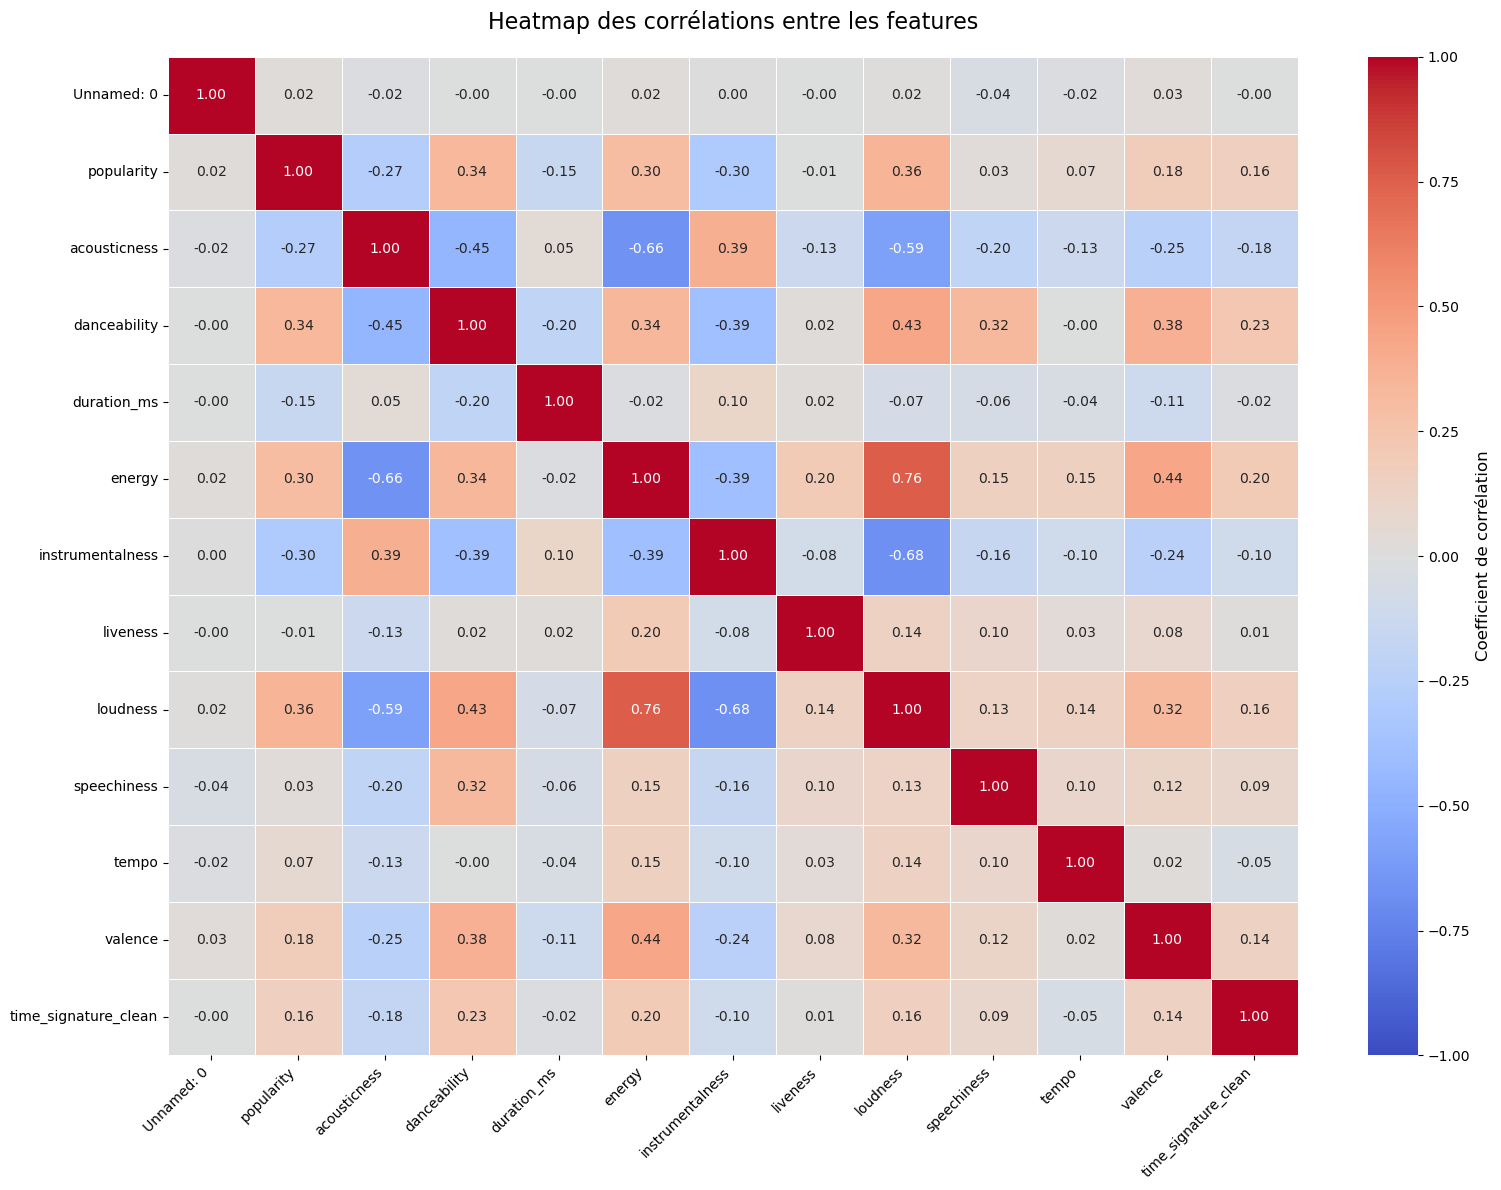

In [52]:

# Sélection uniquement des colonnes numériques pour la corrélation
# Cela exclut les colonnes de texte qui ne peuvent pas être corrélées numériquement
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcul de la matrice de corrélation
# La méthode .corr() calcule les coefficients de corrélation de Pearson par défaut
correlation_matrix = df_numeric.corr()

# Configuration de la figure matplotlib avec une taille appropriée
plt.figure(figsize=(16, 12))  # Ajustez la taille selon le nombre de variables

# Création de la heatmap avec seaborn
# vmin et vmax définissent l'échelle de couleurs (typiquement -1 à 1 pour des corrélations)
# annot=True affiche les valeurs de corrélation dans chaque cellule
# cmap définit la palette de couleurs (ici 'coolwarm' montre les corrélations négatives en bleu et positives en rouge)
# fmt='.2f' limite l'affichage à 2 décimales
# linewidths ajoute une fine ligne blanche entre les cellules pour améliorer la lisibilité
heatmap = sns.heatmap(correlation_matrix, 
                      annot=True,  # Afficher les valeurs
                      fmt='.2f',  # Format à 2 décimales
                      cmap='coolwarm',  # Palette de couleurs
                      linewidths=0.5,  # Lignes blanches entre les cellules
                      vmin=-1,  # Valeur minimale de l'échelle
                      vmax=1)  # Valeur maximale de l'échelle

# Ajout de titres et ajustements
plt.title('Heatmap des corrélations entre les features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotation des étiquettes x pour éviter le chevauchement
plt.yticks(fontsize=10)

# Ajout d'une barre de couleur qui explique l'échelle
cbar = heatmap.collections[0].colorbar
cbar.ax.set_ylabel('Coefficient de corrélation', fontsize=12)

# Ajustement automatique pour que tout soit visible
plt.tight_layout()

# Affichage de la heatmap
plt.show()

# Si vous souhaitez enregistrer l'image
# plt.savefig('heatmap_correlation.png', dpi=300, bbox_inches='tight')


In [53]:
# Corrélations :

# HUMEUR

    # Valence :
        # Valence/energy : 0,44

    # acoustisness :
        # acoustisness/energy : -0,66
        # acoustiness/loudness : -0,59

    # loudness :
        #loudness/acoustisness : -0,59
        #loudness/energy : 0.76 
        #loudness/instrumentalness : -0,68

# ACTIVITE

    # danceabily:
        # danceabilty/acoustisness : -0,45
        # danceabilty/loudness : 0,43

    # energy :
        #energy/acoustisness : -0,66
        #energy/loudness : 0,76
        #energy/valence : 0,44

    #instrumentalness :
        #instrumentalness/loudness : -0,68
    
    #tempo : 
        #tempo/energy : 0,15



# TOP corrélation : 
    #loudness/energy : 0.76
    #energy/loudness : 0,76
    #loudness/instrumentalness : -0,68
    #instrumentalness/loudness : -0,68
    # acoustiness/loudness : -0,59
    #loudness/acoustisness : -0,59

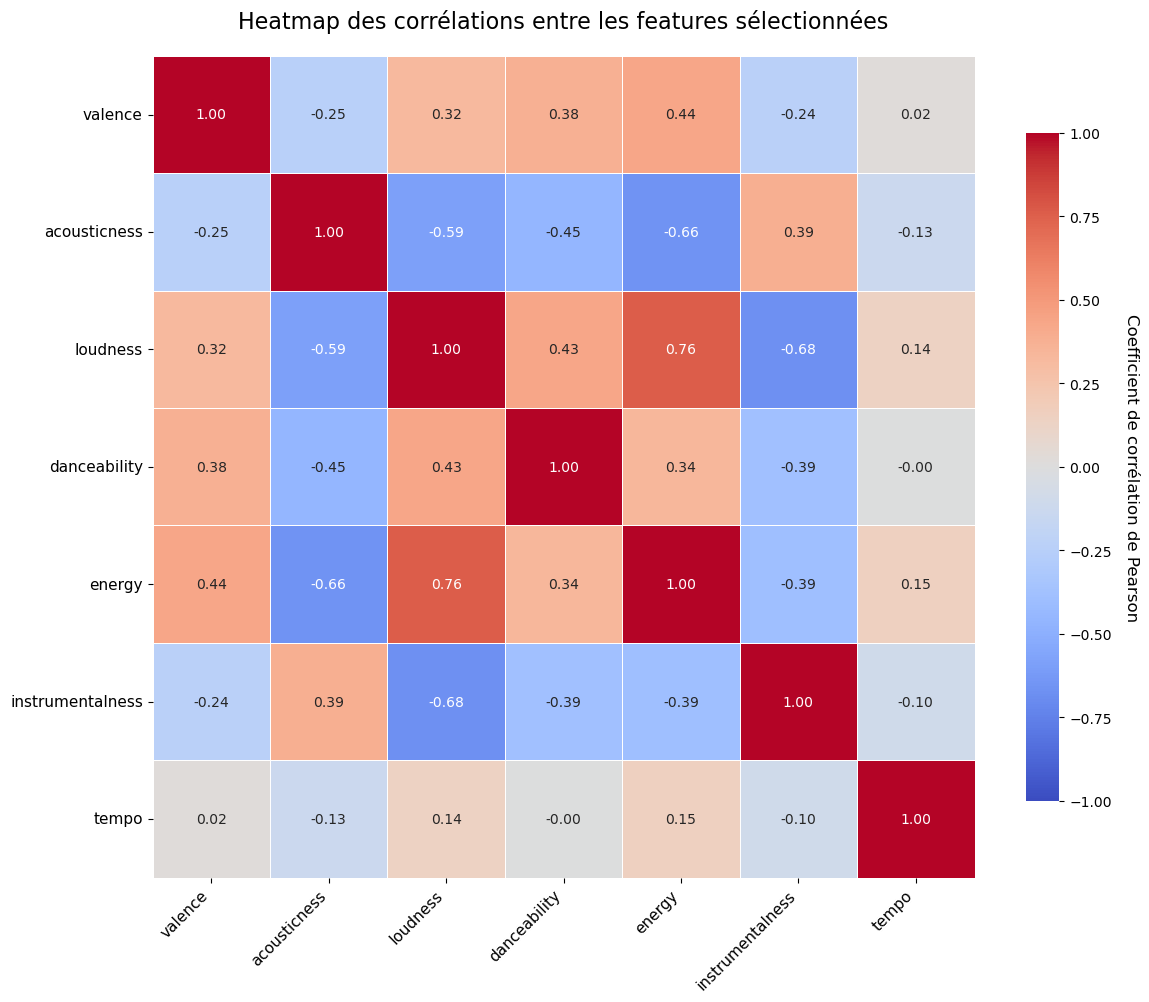

=== ANALYSE DES CORRÉLATIONS ===
Nombre de features analysées : 7
Taille de l'échantillon : 4896 observations

=== TOP 5 DES CORRÉLATIONS LES PLUS FORTES ===
energy <-> loudness: 0.764
instrumentalness <-> loudness: -0.678
energy <-> acousticness: -0.664
loudness <-> acousticness: -0.592
danceability <-> acousticness: -0.454

=== CORRÉLATIONS FAIBLES (|r| < 0.3) ===
Nombre de paires faiblement corrélées : 8
acousticness <-> valence: -0.250
instrumentalness <-> valence: -0.237
tempo <-> energy: 0.152
tempo <-> loudness: 0.140
tempo <-> acousticness: -0.131
tempo <-> instrumentalness: -0.100
tempo <-> valence: 0.019
tempo <-> danceability: -0.003


In [54]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour la manipulation des DataFrames
import numpy as np  # Pour les opérations numériques
import matplotlib.pyplot as plt  # Pour la création de graphiques
import seaborn as sns  # Pour les visualisations statistiques avancées


# Définition des colonnes à conserver pour l'analyse de corrélation
# Liste des features musicales sélectionnées (je corrige "acoustisness" en "acousticness")
selected_features = [
    'valence',         # Mesure de la positivité émotionnelle de la musique (0.0 à 1.0)
    'acousticness',    # Mesure du caractère acoustique de la musique (0.0 à 1.0)
    'loudness',        # Volume général de la piste en décibels (dB)
    'danceability',    # Mesure de la facilité à danser sur cette musique (0.0 à 1.0)
    'energy',          # Mesure de l'intensité et de la puissance perçue (0.0 à 1.0)
    'instrumentalness', # Probabilité que la piste soit instrumentale (0.0 à 1.0)
    'tempo'            # Tempo estimé de la piste en battements par minute (BPM)
]

# Sélection des colonnes spécifiées dans le DataFrame
# Cette opération crée un nouveau DataFrame avec seulement les colonnes voulues
df_selected = df[selected_features].copy()

# Suppression des lignes contenant des valeurs manquantes
# dropna() enlève toutes les lignes qui ont au moins une valeur NaN
# Ceci garantit que le calcul de corrélation fonctionne correctement
df_selected = df_selected.dropna()

# Calcul de la matrice de corrélation de Pearson
# corr() calcule les coefficients de corrélation entre toutes les paires de variables
# Par défaut, utilise la méthode de Pearson qui mesure les relations linéaires
correlation_matrix = df_selected.corr()

# Configuration de la taille de la figure matplotlib
# figsize=(12, 10) définit la largeur et hauteur en pouces
# Une taille adaptée pour 7 variables permet une bonne lisibilité
plt.figure(figsize=(12, 10))

# Création de la heatmap avec seaborn
# sns.heatmap() crée une carte de chaleur des corrélations
heatmap = sns.heatmap(
    correlation_matrix,    # Données à visualiser (matrice de corrélation)
    annot=True,           # annot=True affiche les valeurs numériques dans chaque cellule
    fmt='.2f',            # fmt='.2f' formate les nombres à 2 décimales
    cmap='coolwarm',      # Palette de couleurs : bleu pour négatif, rouge pour positif
    linewidths=0.5,       # Largeur des lignes séparant les cellules (en points)
    square=True,          # square=True force les cellules à être carrées
    vmin=-1,              # Valeur minimale de l'échelle de couleurs
    vmax=1,               # Valeur maximale de l'échelle de couleurs
    center=0,             # center=0 centre la palette de couleurs sur zéro
    cbar_kws={'shrink': 0.8}  # Paramètres de la barre de couleur (réduction à 80%)
)

# Configuration du titre principal du graphique
# title() ajoute un titre avec une police de taille 16 et un espacement de 20 points
plt.title('Heatmap des corrélations entre les features sélectionnées', 
          fontsize=16, pad=20)

# Rotation des étiquettes de l'axe x pour éviter le chevauchement
# xticks() configure l'affichage des étiquettes de l'axe x
# rotation=45 fait tourner les labels de 45 degrés
# ha='right' aligne horizontalement les labels à droite
plt.xticks(rotation=45, ha='right', fontsize=11)

# Configuration des étiquettes de l'axe y
# yticks() configure l'affichage des étiquettes de l'axe y
plt.yticks(fontsize=11, rotation=0)

# Configuration de la barre de couleur (colorbar)
# Récupération de l'objet colorbar pour le personnaliser
cbar = heatmap.collections[0].colorbar
# Ajout d'un label explicatif sur la barre de couleur
cbar.ax.set_ylabel('Coefficient de corrélation de Pearson', 
                   fontsize=12, rotation=270, labelpad=20)

# Ajustement automatique de la mise en page
# tight_layout() optimise l'espacement pour éviter que les éléments se chevauchent
plt.tight_layout()

# Affichage du graphique à l'écran
# show() rend le graphique visible dans l'interface utilisateur
plt.show()

# Option pour sauvegarder le graphique (décommentez si nécessaire)
# plt.savefig('heatmap_features_selected.png', dpi=300, bbox_inches='tight')

# Affichage des statistiques descriptives de la matrice de corrélation
print("=== ANALYSE DES CORRÉLATIONS ===")
print(f"Nombre de features analysées : {len(selected_features)}")
print(f"Taille de l'échantillon : {len(df_selected)} observations")

# Identification des corrélations les plus fortes (en valeur absolue)
# np.triu() crée un masque triangulaire supérieur pour éviter les doublons
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Application du masque pour ne garder que la partie triangulaire inférieure
correlation_matrix_masked = correlation_matrix.mask(mask)

# Conversion en format long pour faciliter l'analyse
# stack() convertit la matrice en série avec index multi-niveau
correlation_pairs = correlation_matrix_masked.stack().reset_index()
correlation_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

# Tri par valeur absolue de corrélation (plus fortes corrélations en premier)
correlation_pairs['Abs_Correlation'] = correlation_pairs['Correlation'].abs()
correlation_pairs_sorted = correlation_pairs.sort_values('Abs_Correlation', 
                                                        ascending=False)

print("\n=== TOP 5 DES CORRÉLATIONS LES PLUS FORTES ===")
# Affichage des 5 corrélations les plus importantes
for i, row in correlation_pairs_sorted.head().iterrows():
    print(f"{row['Feature1']} <-> {row['Feature2']}: {row['Correlation']:.3f}")

print("\n=== CORRÉLATIONS FAIBLES (|r| < 0.3) ===")
# Identification des paires avec corrélations faibles
weak_correlations = correlation_pairs_sorted[
    correlation_pairs_sorted['Abs_Correlation'] < 0.3
]
print(f"Nombre de paires faiblement corrélées : {len(weak_correlations)}")
for i, row in weak_correlations.iterrows():
    print(f"{row['Feature1']} <-> {row['Feature2']}: {row['Correlation']:.3f}")


In [60]:
def creer_tags_manuel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute deux colonnes :
      - tags_humeur  : #joyeux, #triste, #energique, #calme
      - tags_activité: #dance/#fête, #concentration/#travail,
                       #sport/#cardio, #meditation/#yoga
    """
    # Définition du tag d’humeur
    def tag_humeur(valence, acousticness, loudness):
        if valence >= 0.75:
            return "#joyeux"
        if valence < 0.25:
            return "#triste"
        if loudness >= -20 or acousticness < 0.3:
            return "#energique"
        return "#calme"

    # Définition du tag d’activité
    def tag_activite(danceability, energy, tempo):
        if danceability >= 0.5:
            return "#dance/#fête"
        if energy >= 0.6 or tempo >= 110:
            return "#sport/#cardio"
        if energy >= 0.3:
            return "#concentration/#travail"
        return "#meditation/#yoga"

    # Application ligne par ligne
    df["tags_humeur"] = df.apply(
        lambda r: tag_humeur(r["valence"], r["acousticness"], r["loudness"]), axis=1
    )
    df["tags_activité"] = df.apply(
        lambda r: tag_activite(r["danceability"], r["energy"], r["tempo"]), axis=1
    )

    # Vérification des tags uniques et comptages
    uniques_humeur = df["tags_humeur"].unique().tolist()
    compte_humeur = df["tags_humeur"].value_counts().reset_index()
    compte_humeur.columns = ["tag_humeur", "occurrences"]

    uniques_activite = df["tags_activité"].unique().tolist()
    compte_activite = df["tags_activité"].value_counts().reset_index()
    compte_activite.columns = ["tag_activité", "occurrences"]

    # Affichage des vérifications
    print("Tags d’humeur uniques :", uniques_humeur)
    print("\nRépartition des tags d’humeur :")
    print(compte_humeur)

    print("\nTags d’activité uniques :", uniques_activite)
    print("\nRépartition des tags d’activité :")
    print(compte_activite)

    return df


df_tagged = creer_tags_manuel(df)
df_tagged


Tags d’humeur uniques : ['#energique', '#joyeux', '#triste', '#calme']

Répartition des tags d’humeur :
   tag_humeur  occurrences
0  #energique         3153
1     #triste         1200
2     #joyeux          522
3      #calme           21

Tags d’activité uniques : ['#sport/#cardio', '#meditation/#yoga', '#dance/#fête', '#concentration/#travail']

Répartition des tags d’activité :
              tag_activité  occurrences
0             #dance/#fête         3860
1           #sport/#cardio          631
2  #concentration/#travail          210
3        #meditation/#yoga          195


,Unnamed: 0,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,tempo,time_signature,valence,time_signature_clean,genre_group,artist_normalized,genre_simplifié,origine,tags_humeur,tags_activité
0,38149.0,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,62,0.2980,0.410,320027,0.468,0.000012,...,177.508,4,0.4750,4.0,Autres,paula cole,jazz/blues,origine_historique,#energique,#sport/#cardio
1,37124.0,mellow fellow,how was your day?,2E01rRrzaz6TuwCdm27m4m,62,0.0472,0.447,188787,0.442,0.000559,...,159.967,4,0.7760,4.0,Autres,mellow fellow,jazz/blues,origine_historique,#joyeux,#sport/#cardio
2,81461.0,marcell,takkan terganti,0T4t1PywlNmJGcveGH5spB,63,0.7040,0.358,241763,0.275,0.000001,...,103.581,4,0.1170,4.0,Autres,marcell,jazz/blues,origine_historique,#triste,#meditation/#yoga
3,29.0,giacomo puccini,"""nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.9610,0.171,180933,0.308,0.005460,...,171.798,5,0.0889,5.0,Autres,giacomo puccini,jazz/blues,origine_historique,#triste,#sport/#cardio
4,37015.0,david crowder band,how he loves,6WSFMa721PvfnspCRsGOMh,63,0.0167,0.217,318693,0.466,0.000026,...,149.398,3,0.1730,3.0,Autres,david crowder band,jazz/blues,origine_historique,#triste,#sport/#cardio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,9607.0,fergie,big girls don't cry (personal),3Q4WeJmzxuDpzMu9QjQqbM,75,0.2390,0.712,268120,0.647,0.000000,...,113.116,4,0.2920,4.0,Autres,fergie,électro/dance,origine_historique,#energique,#dance/#fête
4892,37970.0,cardi b,i do (feat. sza),1f5PNhkNgUpvDEeZfcIlO1,75,0.2700,0.886,200205,0.473,0.000026,...,135.065,4,0.4380,4.0,Autres,cardi b,électro/dance,origine_historique,#energique,#dance/#fête
4893,38790.0,g-eazy,i mean it,6jmTHeoWvBaSrwWttr8Xvu,75,0.1250,0.712,236480,0.562,0.000000,...,140.000,4,0.1420,4.0,Autres,g-eazy,électro/dance,origine_historique,#triste,#dance/#fête
4894,64338.0,shakira,perro fiel (feat. nicky jam),70lnL3QaSOIIyMa2X9aVRL,75,0.1870,0.750,195213,0.760,0.000000,...,183.817,4,0.8930,4.0,Autres,shakira,électro/dance,origine_historique,#joyeux,#dance/#fête


In [66]:
df_tagged.loc[:, ["artist_name", "track_name", "track_id", "genre_simplifié"]]


,artist_name,track_name,track_id,genre_simplifié
0,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,jazz/blues
1,mellow fellow,how was your day?,2E01rRrzaz6TuwCdm27m4m,jazz/blues
2,marcell,takkan terganti,0T4t1PywlNmJGcveGH5spB,jazz/blues
3,giacomo puccini,"""nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,jazz/blues
4,david crowder band,how he loves,6WSFMa721PvfnspCRsGOMh,jazz/blues
...,...,...,...,...
4891,fergie,big girls don't cry (personal),3Q4WeJmzxuDpzMu9QjQqbM,électro/dance
4892,cardi b,i do (feat. sza),1f5PNhkNgUpvDEeZfcIlO1,électro/dance
4893,g-eazy,i mean it,6jmTHeoWvBaSrwWttr8Xvu,électro/dance
4894,shakira,perro fiel (feat. nicky jam),70lnL3QaSOIIyMa2X9aVRL,électro/dance
